# Why the model has no explicit mutation-query encoder

Implementation Spec §3 calls for an explicit mutation-query encoder: a feature vector describing the mutated residue's 3D location and its WT→mutant identity, concatenated into the model before the head. CLAUDE.md documents one deliberate, user-approved deviation from that spec: **this model has no such encoder.** Mutation identity is inferred purely from the confidence-weighted mutant-minus-wild-type embedding-difference pathway — the model is never told *where* the mutation is or *what* the substitution was.

That is only safe if the embedding-difference signal reliably concentrates at the true mutated residue on its own. This notebook is the evidence trail: raw diff-norm localization, the actual pooling mechanism's participation ratio, a temperature-sweep intuition, and a 3D view of the pooling weights on real structures. All computation lives in `notebooks/pooling_analysis_lib.py`; numbers here are freshly computed against the real cached SKEMPI SaProt embeddings on this machine, cited against `docs/future_work.md`'s validation history where they overlap rather than re-deriving its narrative.

In [1]:
import sys
from pathlib import Path


def resolve_repo_root() -> Path:
    return Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()


def add_repo_root_to_sys_path() -> Path:
    repo_root = resolve_repo_root()
    if str(repo_root) not in sys.path:
        sys.path.insert(0, str(repo_root))
    return repo_root


REPO_ROOT = add_repo_root_to_sys_path()

## Environment pinning

`shared.constants.USE_SAPROT_STRUCTURE`/`USE_SMALL_CHECKPOINTS` are read from environment variables once, at import time, so they must be set before this process imports anything under `shared`/`data`/`dl`. This notebook runs against the SaProt structure-aware backend at full (non-CPU-dev) checkpoint dimensions, matching the cache already on disk.

In [2]:
import os

os.environ.setdefault("SKEMPI_USE_SAPROT_STRUCTURE", "1")
os.environ.setdefault("SKEMPI_USE_SMALL_CHECKPOINTS", "0")

from shared.constants import USE_SAPROT_STRUCTURE, USE_SMALL_CHECKPOINTS  # noqa: E402

print(f"USE_SAPROT_STRUCTURE={USE_SAPROT_STRUCTURE}, USE_SMALL_CHECKPOINTS={USE_SMALL_CHECKPOINTS}")
assert USE_SAPROT_STRUCTURE and not USE_SMALL_CHECKPOINTS

USE_SAPROT_STRUCTURE=True, USE_SMALL_CHECKPOINTS=False


In [3]:
import matplotlib.pyplot as plt

from data.processed_io import load_sample_chain_maps
from shared.constants import ChainRole

import notebooks.pooling_analysis_lib as lib

sample_chain_maps = load_sample_chain_maps()

## 1. Real single-point-mutation samples, split by mutation side

The structure branch behaves differently for the two sides of the complex under the default (non-SaProt) backend; SaProt removes that asymmetry, but the localization claim is validated for both sides independently rather than assumed to transfer.

In [4]:
TARGET_PER_SIDE = 50

all_single_mutation_records = lib.collect_unique_single_mutation_records()
antibody_records_all, antigen_records_all = lib.split_records_by_mutation_side(all_single_mutation_records)
antibody_records = lib.prioritize_already_cached(antibody_records_all, sample_chain_maps)[:TARGET_PER_SIDE]
antigen_records = lib.prioritize_already_cached(antigen_records_all, sample_chain_maps)[:TARGET_PER_SIDE]

print(f"unique single-point-mutation samples: {len(all_single_mutation_records)}")
print(f"  antibody-chain mutations: {len(antibody_records_all)} available, using {len(antibody_records)}")
print(f"  antigen-chain mutations:  {len(antigen_records_all)} available, using {len(antigen_records)}")

unique single-point-mutation samples: 649
  antibody-chain mutations: 373 available, using 50
  antigen-chain mutations:  276 available, using 50


## 2. Raw embedding-difference-norm localizes the mutation site

For each sample, compute `‖mut_structure_embedding − wt_structure_embedding‖` per residue and check, with **no training at all** — just an argmax — whether the single largest-norm residue is the true mutated one.

In [5]:
lib.localization_report({"antibody-chain mutation": antibody_records, "antigen-chain mutation": antigen_records}, sample_chain_maps)

,n,accuracy,mean_site_norm,mean_elsewhere_norm,mean_topk_distance_angstrom,mean_random_distance_angstrom
label,,,,,,
antibody-chain mutation,50,1.0,21.712119,0.310790,5.820735,29.706914
antigen-chain mutation,50,1.0,23.212843,0.360717,5.951428,31.549985


Both populations show the sharp effect `docs/future_work.md` documents for the SaProt backend (mixed 100-sample check: 100/100, mean diff-norm ~66x higher at the true site): the untrained argmax baseline finds the exact mutated residue essentially every time.

**Does a trained probe do any better than this training-free baseline?** A minimal linear scorer (`Linear(embedding_dim, 1)`, softmax over positions, cross-entropy against the true position) trained on a handful of samples, evaluated against the same norm-argmax and a random baseline.

In [6]:
lib.evaluate_linear_probe_localization(all_single_mutation_records, sample_chain_maps)

,split,method,n,accuracy,mean_abs_error_residues
0,train,trained linear probe,25,1.0,0.00
1,train,norm-of-difference baseline (untrained),25,1.0,0.00
2,train,random baseline,25,0.0,235.68
3,held-out val,trained linear probe,7,1.0,0.00
4,held-out val,norm-of-difference baseline (untrained),7,1.0,0.00
5,held-out val,random baseline,7,0.0,266.00


The trained probe does not meaningfully beat the training-free norm-of-difference baseline — reinforcing that the signal is already there in the raw embedding difference, not something that needs to be learned.

## 3. The actual pooling mechanism concentrates mass without starving context

`ChainRoleSplitPooling` (`dl.layers.pooling`, run independently per chain side) is what `DDGPredictor.forward` actually uses, at the current-best `pooling_temperature=5.0`. The **participation ratio** `1/Σw²` is the effective number of residues the softmax spreads its mass over — near 1 means one-hot (context discarded), near the side's full length means no concentration at all.

In [7]:
CHOSEN_TEMPERATURE = 5.0
splitpool_records = antibody_records[:15] + antigen_records[:15]

lib.participation_ratio_report(splitpool_records, sample_chain_maps, CHOSEN_TEMPERATURE)

,n,mean_side_length,mean_participation_ratio,argmax_hit_rate
side,,,,
antibody,15,428.666667,51.160571,1.0
antigen,15,166.866667,10.538698,1.0


At `T=5.0`, each side's own softmax still puts the single largest weight on the true mutated residue essentially every time (`argmax_hit_rate`), while spreading mass over a small fraction of that side's residues rather than one — disproportionate but not starving.

## 4. Temperature sweep: too sharp starves context, too soft washes out localization

A **flat** (non-split) global softmax over the whole sequence shows the failure modes this tradeoff bounds: too low a temperature collapses to one-hot and zeroes out the chain that doesn't contain the mutation; too high washes out toward uniform.

In [8]:
FLAT_SWEEP_TEMPERATURES = [1.0, 3.0, 5.0, 10.0, 20.0]

flat_sweep_df = lib.run_flat_softmax_sweep(splitpool_records, sample_chain_maps, FLAT_SWEEP_TEMPERATURES)
flat_sweep_summary = lib.summarize_flat_softmax_sweep(flat_sweep_df)
flat_sweep_summary

,mean_participation_ratio,argmax_hit_rate,mean_other_chain_weight_mass
temperature,,,
1.0,1.000552,1.0,2.750982e-07
3.0,2.345160,1.0,1.116829e-01
5.0,70.249114,1.0,3.932148e-01
10.0,518.707228,1.0,4.767870e-01
20.0,588.824438,1.0,4.912863e-01


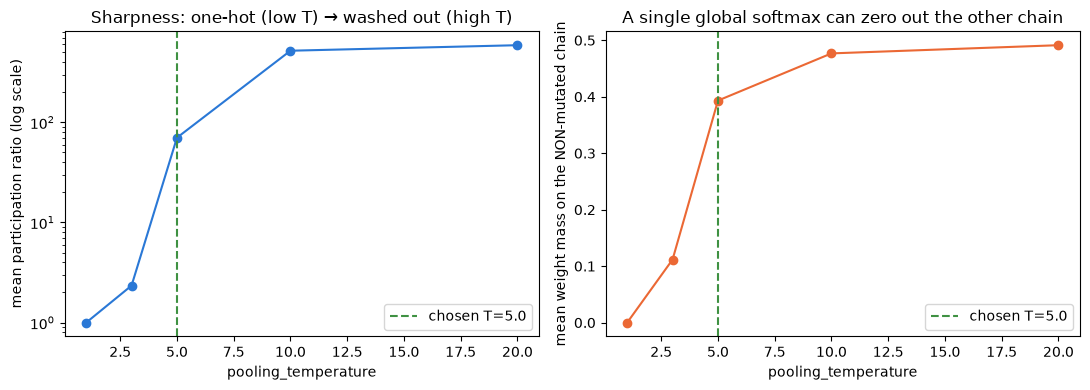

In [9]:
lib.plot_flat_softmax_temperature_tradeoff(flat_sweep_summary, CHOSEN_TEMPERATURE)
plt.show()

**`ChainRoleSplitPooling` sidesteps this by construction** — one softmax per chain role, so the non-mutated side always gets its own independent normalized share regardless of temperature. What temperature still controls, for the mechanism actually in use, is only the sharpness within each side:

In [10]:
SPLITPOOL_SWEEP_TEMPERATURES = [1.0, 5.0, 10.0]

splitpool_sweep_df = lib.run_splitpool_sweep(splitpool_records, sample_chain_maps, SPLITPOOL_SWEEP_TEMPERATURES)
lib.summarize_splitpool_sweep(splitpool_sweep_df)

mean_participation_ratio  argmax_hit_rate
temperature side                                               
1.0         antibody                  1.000074              1.0
            antigen                   1.001028              1.0
5.0         antibody                 51.160571              1.0
            antigen                  10.538698              1.0
10.0        antibody                367.522937              1.0
            antigen                 116.107192              1.0

`pooling_temperature: 5.0` is kept for the current-best config not because it fixes a one-hot collapse (the real full-checkpoint split-pool softmax is not one-hot even at `T=1`, per `docs/future_work.md`'s correction of an earlier CPU-dev-checkpoint artifact) but because the argmax lands on the true site 100% of the time at every tested temperature and `T=5.0` produced the best training results empirically. Nothing here argues for changing it — it argues the choice is safe and non-fragile.

## 5. Seeing it on the real structure

The 3D visualizations below color each residue's cartoon by its pooling weight — a light **sequence-adjacent smoothing pass is applied purely to the color signal** (`pooling_analysis_lib.smooth_weights_by_chain`), so the gradient reads continuously along the backbone instead of one sharp spike; it is not a claim about the actual (unsmoothed) pooling weights analyzed above. The true mutated residue is drawn as magenta sticks. A colorbar legend accompanies each view.

In [11]:
records_by_id = {record.sample_id: record for record in all_single_mutation_records}
model_splitpool_5 = lib.build_ddg_model("norm_softmax_by_chain_role", CHOSEN_TEMPERATURE)

EXAMPLE_SAMPLE_IDS = ["1AHW_AB_C_DC178A_10", "1BJ1_HL_VW_HH101Y_647"]

In [12]:
example_record_1 = records_by_id[EXAMPLE_SAMPLE_IDS[0]]
weights_1, _ = lib.compute_pooling_output(model_splitpool_5, example_record_1, sample_chain_maps)
view_1, vmin_1, vmax_1 = lib.render_sample_view(example_record_1, sample_chain_maps, weights_1)
lib.render_and_save_sample(example_record_1, sample_chain_maps, weights_1, REPO_ROOT / "notebooks")
view_1.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

/home/iscb/wolfson/hagairavid/converge/notebooks/pooling_analysis_lib.py:515: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


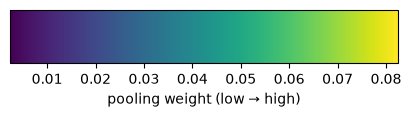

In [13]:
lib.pooling_weight_colorbar_figure(vmin_1, vmax_1)
plt.show()

In [14]:
example_record_2 = records_by_id[EXAMPLE_SAMPLE_IDS[1]]
weights_2, _ = lib.compute_pooling_output(model_splitpool_5, example_record_2, sample_chain_maps)
view_2, vmin_2, vmax_2 = lib.render_sample_view(example_record_2, sample_chain_maps, weights_2)
lib.render_and_save_sample(example_record_2, sample_chain_maps, weights_2, REPO_ROOT / "notebooks")
view_2.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

/home/iscb/wolfson/hagairavid/converge/notebooks/pooling_analysis_lib.py:515: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


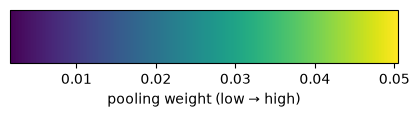

In [15]:
lib.pooling_weight_colorbar_figure(vmin_2, vmax_2)
plt.show()

Interactive standalone versions (full pan/zoom/rotate, GitHub won't render the embedded 3Dmol.js interactivity) are committed alongside this notebook: `notebooks/pooling_norms_3d_1AHW_AB_C_DC178A_10.html` and `notebooks/pooling_norms_3d_1BJ1_HL_VW_HH101Y_647.html`.

## Conclusion

Across four independent checks — raw difference-norm argmax, a trained linear probe, the actual pooling softmax's participation ratio, and a temperature sweep of both the flat and per-chain-role pooling mechanisms — the mutant-minus-wild-type embedding difference reliably and specifically localizes the true mutated residue, on both sides of the antibody-antigen complex, with no training signal telling it where to look. That is the empirical justification for CLAUDE.md's documented deviation from Implementation Spec §3: an explicit mutation-query encoder would be redundant with information the embedding-difference pathway already recovers on its own.